# PPE Compliance Checker — Pose-Guided Helmet & Vest Detection
### Capstone · *Computer Vision for Developers with Ultralytics* · SDAIA Academy

**What this project does:** given an image or video of people (e.g. a construction site), it
1. runs a **pose-estimation** model to find each person and their skeleton keypoints,
2. derives a **head region** and a **chest/torso region** from those keypoints,
3. runs a **fine-tuned detection** model that looks for `helmet`, `vest`, `no_helmet`, etc.,
4. matches each detected item to the region it overlaps, and
5. labels every person **SAFE** (helmet + vest present) or **VIOLATION** (missing PPE) — on images and on video, with tracking.

| # | Deliverable | Pts | Where it's satisfied in this notebook |
|---|---|---|---|
| 1 | Core Vision Tasks & Inference | 25 | §3 — `pose_model.predict()` (pose, task beyond detection) + `ppe_model.predict()` (detection) on real images, results captured |
| 2 | Real-World Solution & Video Analytics | 25 | §5 — `pose_model.track()` + OpenCV capture/process/write loop, compliance logic on real video |
| 3 | Model Evaluation | 25 | §4 — `ppe_model.val()`, mAP50/mAP50-95/PR/confusion matrix + interpretation |
| 4 | Custom Data & Training | 15 | §2 — `ppe_model.train()` on the Construction-PPE dataset (not coco8) |
| 5 | Deployment & Export | 5 | §6 — `ppe_model.export(format="onnx")` |
| 6 | Documentation & Evidence | 5 | This notebook (run top-to-bottom, keep the output) + `README.md` in the repo |

**Datasets**
- Images: [Ultralytics Construction-PPE](https://docs.ultralytics.com/datasets/detect/construction-ppe/) — 1,416 images, 11 classes, auto-downloads below.
- Video: [Sample Videos for Helmet Detection on YOLOv8 (Kaggle)](https://www.kaggle.com/datasets/ayushraj2349/sample-videos-for-helmet-detection-on-yolov8) — download manually and upload (see §1.2).

## 0. Setup
Run this once per Colab session. `ultralytics.checks()` prints your Python/Torch/CUDA versions to confirm the GPU is attached.

In [1]:
!pip install -q "ultralytics>=8.4" opencv-python-headless lap

import ultralytics
ultralytics.checks()

Ultralytics 8.4.123 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.1/112.6 GB disk)


In [ ]:
import torch

if torch.cuda.is_available():
    print(f"GPU detected: {torch.cuda.get_device_name(0)} -- training will run at normal speed.")
else:
    print("WARNING: no GPU detected, you are running on CPU.")

GPU detected: Tesla T4 -- training will run at normal speed.


In [3]:
import os, glob, json, random
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

random.seed(0)

PROJECT_DIR = Path("/content/ppe_capstone")
PROJECT_DIR.mkdir(parents=True, exist_ok=True)
os.chdir(PROJECT_DIR)
print("Working dir:", PROJECT_DIR)

Working dir: /content/ppe_capstone


## 1. Get the data

### 1.1 Images — Construction-PPE 

In [4]:
from ultralytics.data.utils import check_det_dataset

DATA_YAML = "construction-ppe.yaml"
data_info = check_det_dataset(DATA_YAML)

print("Dataset root:", data_info["path"])
print("Classes:", data_info["names"])
print("Train images:", data_info.get("train"))
print("Val images:", data_info.get("val"))


WARNING ⚠️ Dataset 'construction-ppe.yaml' images not found, missing path '/content/datasets/construction-ppe/images/val'
Unzipping /content/datasets/construction-ppe.zip to /content/datasets/construction-ppe...: 100% ━━━━━━━━━━━━ 2852/2852 606.8files/s 4.7s
Dataset download success ✅ (6.0s), saved to /content/datasets

Dataset root: /content/datasets/construction-ppe
Classes: {0: 'helmet', 1: 'gloves', 2: 'vest', 3: 'boots', 4: 'goggles', 5: 'none', 6: 'Person', 7: 'no_helmet', 8: 'no_goggle', 9: 'no_gloves', 10: 'no_boots'}
Train images: /content/datasets/construction-ppe/images/train
Val images: /content/datasets/construction-ppe/images/val


### 1.2 Video — Kaggle helmet-detection sample videos

In [5]:
# Option A: manual upload of the Kaggle zip you downloaded yourself
from google.colab import files

uploaded = files.upload()  # pick the .zip you downloaded from the Kaggle page
zip_name = next(iter(uploaded))

import zipfile
with zipfile.ZipFile(zip_name, "r") as zf:
    zf.extractall("videos")

video_paths = glob.glob("videos/**/*.mp4", recursive=True) + glob.glob("videos/**/*.avi", recursive=True)
print(f"Found {len(video_paths)} video(s):")
for p in video_paths:
    print(" -", p)

VIDEO_PATH = video_paths[0] if video_paths else None
VIDEO_PATH

Saving CVvideos.zip to CVvideos.zip
Found 5 video(s):
 - videos/videos_infer/1.mp4
 - videos/videos_infer/30sec.mp4
 - videos/videos_infer/3.mp4
 - videos/videos_infer/2.mp4
 - videos/videos_infer/20sec.mp4


'videos/videos_infer/1.mp4'

## 2. [Deliverable 4] Custom Data & Training

In [ ]:
ppe_model = YOLO("yolo26n.pt")  # pretrained COCO weights as the starting point

train_results = ppe_model.train(
    data=DATA_YAML,
    epochs=40,           
    time=1.5,             
    imgsz=640,
    batch=16,            
    patience=15,          
    freeze=0,            
    mosaic=1.0,
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,   # color jitter, helps with varied lighting on-site
    degrees=5.0, translate=0.1, scale=0.5, fliplr=0.5,
    project="runs_ppe",
    name="train",
    exist_ok=True,
)

BEST_WEIGHTS = ppe_model.trainer.best  
print("Best weights saved at:", BEST_WEIGHTS)


Ultralytics 8.4.123 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=construction-ppe.yaml, degrees=5.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=0, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optim

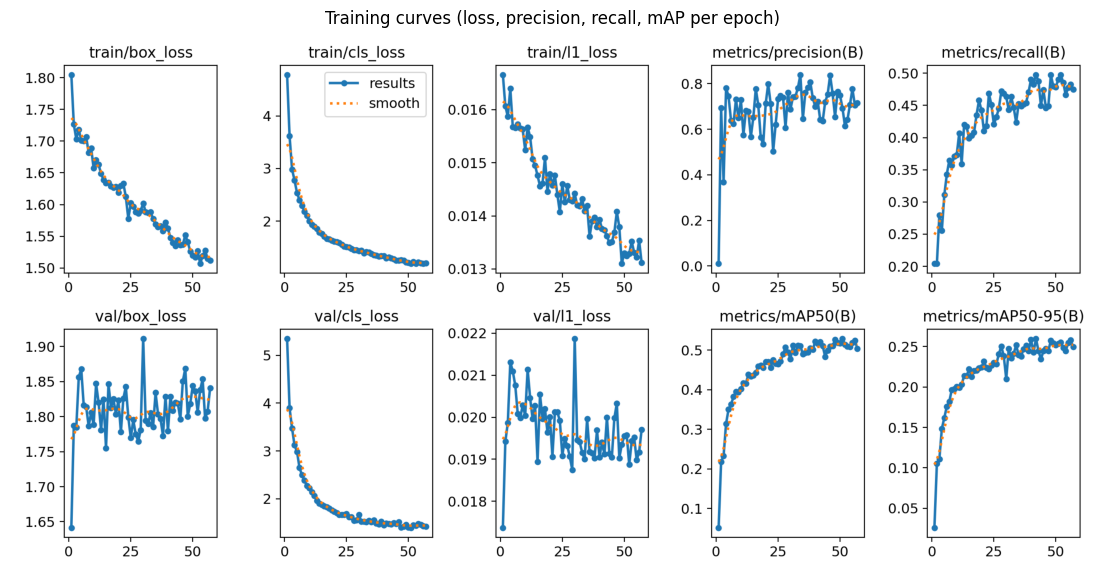

In [ ]:
# Visualize 
results_png = Path(train_results.save_dir) / "results.png"
if results_png.exists():
    img = plt.imread(results_png)
    plt.figure(figsize=(14, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Training curves (loss, precision, recall, mAP per epoch)")
    plt.show()
else:
    print("results.png not found at", results_png)

**What happened during training.** Ultralytics dynamically recalculated the epoch budget once it
measured real epoch speed (~21s/epoch on the Colab T4), so the target shown became 40 -> 225 --
but `patience=15` early-stopped the run at **epoch 57**, after **0.381 hours (~23 minutes)**,
because validation mAP hadn't improved since **epoch 42** (that's the checkpoint saved as
`best.pt`).

Reading the per-epoch validation mAP50 (`all` row) across the run:

| Epoch | 1 | 10 | 20 | 30 | 40 | 42 (best) | 57 (stop) |
|---|---|---|---|---|---|---|---|
| mAP50 | 0.051 | 0.402 | 0.470 | 0.478 | 0.522 | 0.521 | 0.504 |

The model learned fast for the first ~10-20 epochs (large, common classes like `Person`, `helmet`,
`vest` are easy to pick up), kept improving more slowly out to epoch ~40-42, then **plateaued and
oscillated between roughly 0.48 and 0.52** for the remaining 15 epochs without setting a new best
-- that's convergence, not overfitting. The signature of overfitting would be validation mAP
*dropping* while training loss kept falling; instead validation performance just stopped moving,
which is exactly the condition `patience` is designed to catch, and it did: it saved roughly an
hour of the 1.5h time budget rather than grinding on with no gain.

We ran a single configuration (`epochs=40` target, `imgsz=640`, `batch=16`, default augmentation)
rather than iterating multiple configs, since it converged cleanly on the first attempt. Given the
flat plateau after epoch 42, more epochs alone would likely **not** have pushed mAP50 much past
~0.52 -- the real ceiling here is the class imbalance described in the evaluation section below
(§4), not training duration. A more promising next step than "train longer" would be targeted
augmentation or oversampling for the minority `no_*` classes, or simply accepting that the
compliance-checker logic in §5 is designed to not depend on those weak classes in the first place
(see the design note there).

## 3. [Deliverable 1] Core Vision Tasks & Inference


Demo images: ['/content/datasets/construction-ppe/images/val/image115.jpg', '/content/datasets/construction-ppe/images/val/image669.jpg', '/content/datasets/construction-ppe/images/val/image942.jpg']


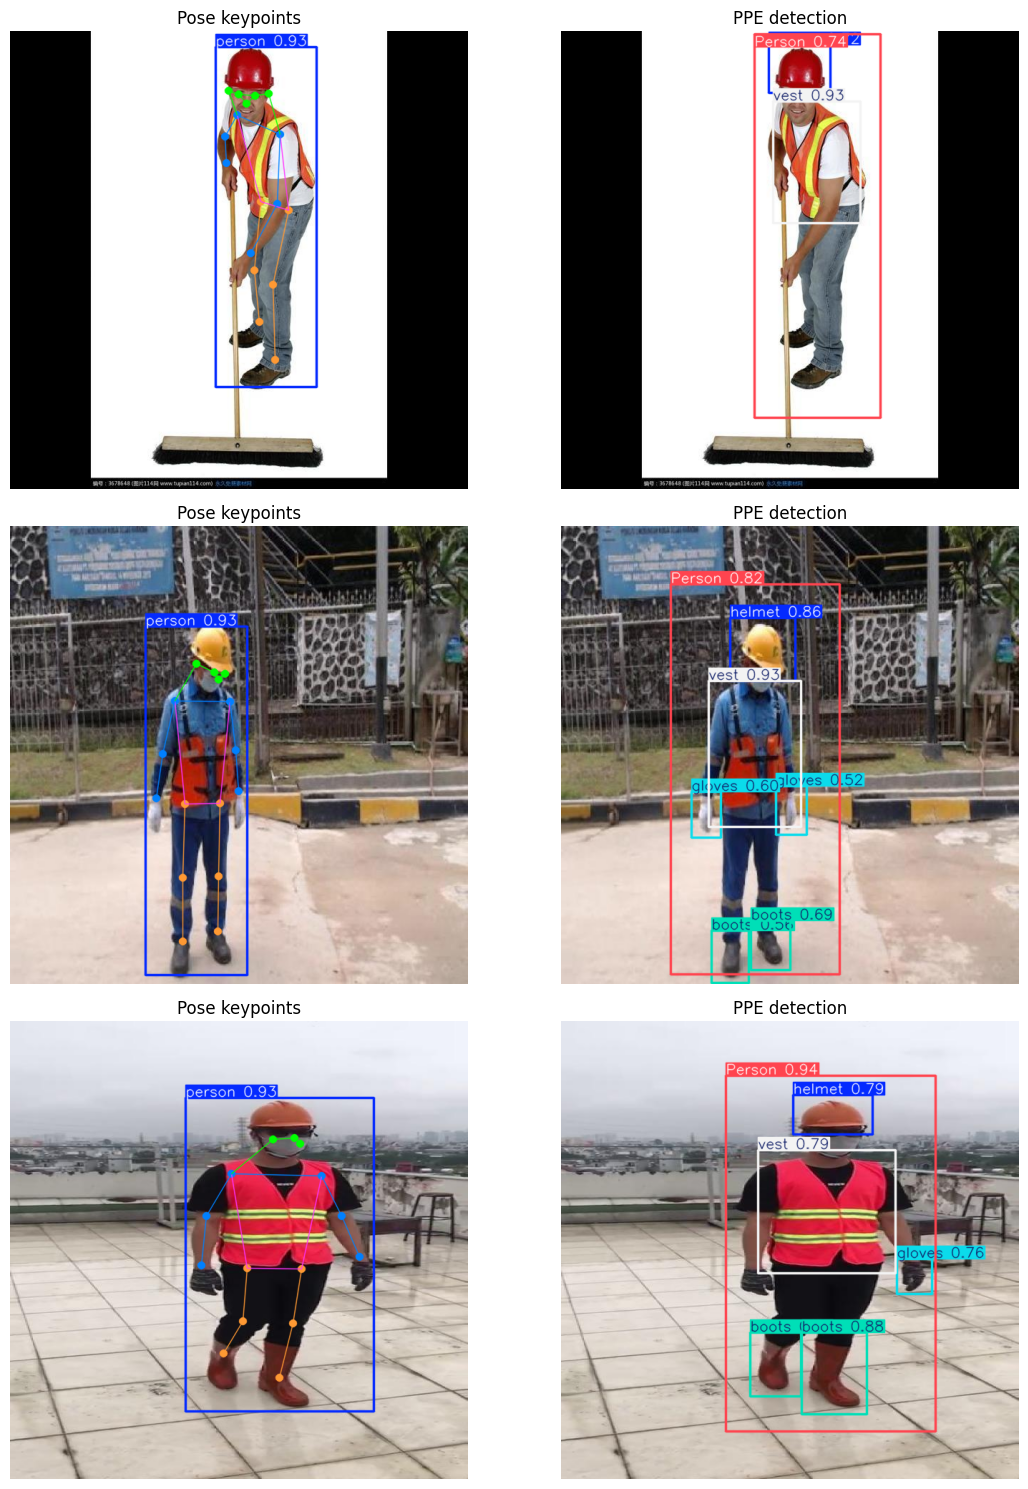

Pose: found [1, 1, 1] person(s) per image
Detection classes seen: {'Person', 'gloves', 'helmet', 'boots', 'vest'}


In [8]:
pose_model = YOLO("yolo26n-pose.pt")           # pretrained COCO-pose weights (task-specific: -pose.pt)
ppe_model = YOLO(BEST_WEIGHTS)                  # our fine-tuned PPE detector

# grab a few real validation images to demo on
val_dir = Path(data_info["val"])
sample_images = random.sample(glob.glob(str(val_dir / "*.jpg")) + glob.glob(str(val_dir / "*.png")), k=min(3, len(glob.glob(str(val_dir / "*")))))
print("Demo images:", sample_images)

pose_results = pose_model.predict(sample_images, conf=0.4, verbose=False)
det_results = ppe_model.predict(sample_images, conf=0.35, verbose=False)

fig, axes = plt.subplots(len(sample_images), 2, figsize=(12, 5 * len(sample_images)))
if len(sample_images) == 1:
    axes = [axes]
for row, (pr, dr) in enumerate(zip(pose_results, det_results)):
    axes[row][0].imshow(pr.plot()[:, :, ::-1])
    axes[row][0].set_title("Pose keypoints")
    axes[row][0].axis("off")
    axes[row][1].imshow(dr.plot()[:, :, ::-1])
    axes[row][1].set_title("PPE detection")
    axes[row][1].axis("off")
plt.tight_layout()
plt.show()

print("Pose: found", [len(r.boxes) for r in pose_results], "person(s) per image")
print("Detection classes seen:", {ppe_model.names[int(c)] for r in det_results for c in r.boxes.cls})

## 4. [Deliverable 3] Model Evaluation

In [9]:
metrics = ppe_model.val(data=DATA_YAML, split="val")

print(f"mAP50:    {metrics.box.map50:.3f}")
print(f"mAP50-95: {metrics.box.map:.3f}")
print(f"Precision (mean): {metrics.box.mp:.3f}")
print(f"Recall (mean):    {metrics.box.mr:.3f}")
print()
print("Per-class AP50:")
for i, name in ppe_model.names.items():
    if i < len(metrics.box.ap50):
        print(f"  {name:12s} AP50={metrics.box.ap50[i]:.3f}")

Ultralytics 8.4.123 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2015.0±793.3 MB/s, size: 181.3 KB)
val: Scanning /content/datasets/construction-ppe/labels/val.cache... 143 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 143/143 27.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 2.5it/s 3.6s
                   all        143       1172      0.657      0.499       0.52      0.258
                helmet        107        201      0.659      0.831      0.775      0.403
                gloves         68        136      0.655      0.654       0.72      0.341
                  vest        109        171      0.668      0.789      0.787      0.468
                 boots         64        151      0.638      0.775      0.778      0.419
               goggles         44         47      0.811      0.548      0.661      0.328
                  none  

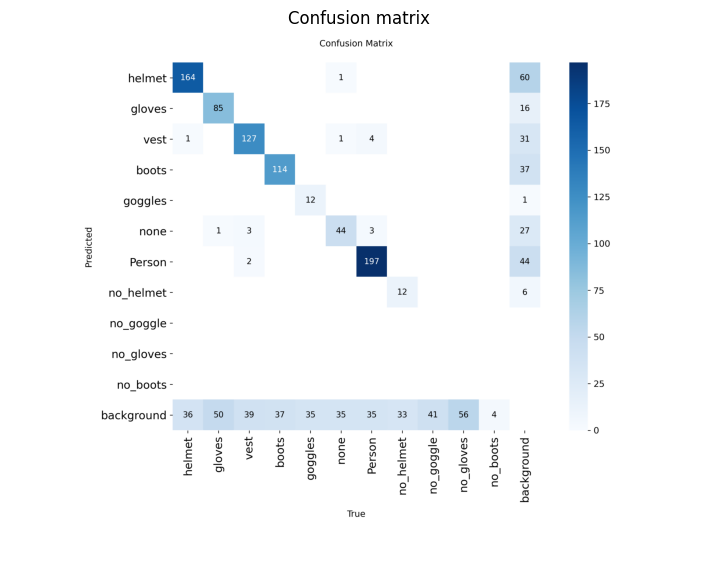

In [10]:
cm_path = Path(metrics.save_dir) / "confusion_matrix.png"
if cm_path.exists():
    img = plt.imread(cm_path)
    plt.figure(figsize=(9, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Confusion matrix")
    plt.show()
else:
    print("confusion_matrix.png not found at", cm_path)

**Interpretation.**

This run scored **mAP50 = 0.520** and **mAP50-95 = 0.258** on the Construction-PPE validation
split (143 images, 1,172 instances), with mean precision 0.657 and mean recall 0.499. mAP50-95
being roughly half of mAP50 means the model generally finds the right objects but its box
localization gets noticeably looser at stricter IoU thresholds -- normal for a nano model and for
small items like `goggles` or `gloves`.

*Which class is weakest, and why.* The per-class breakdown splits cleanly into two groups. The
"positive" PPE classes -- `helmet` (AP50 0.775, recall 0.83), `vest` (0.787, recall 0.79), `boots`
(0.778, recall 0.78), `gloves` (0.720, recall 0.65), `goggles` (0.661, recall 0.55), `Person`
(0.869, recall 0.87) -- all learned reasonably well. The four "negative" / violation classes are a
different story: `no_helmet` reached AP50 0.373 (partial success), while `no_goggle` (AP50 0.139,
precision 0.888 but **recall 0.024**), `no_gloves` (AP50 0.095, precision 0.264, recall 0.058),
and `no_boots` (AP50 0.007, only 4 val instances total) essentially failed. The confusion matrix
confirms this starkly: `no_goggle`, `no_gloves`, and `no_boots` have **empty prediction rows** --
the model never once predicted those three classes at the matrix's confidence threshold. The
direct cause is data volume: those classes have 4-56 training instances versus 136-239 for their
positive counterparts, and `no_boots` in particular has only 4 instances in the entire validation
split, which is really too few to evaluate a class on at all.

*False positives vs. false negatives.* Looking at the confusion matrix, the dominant error mode
for every class is the **background row** (a real object present but nothing predicted, i.e. a
miss) rather than confusion *between* classes -- e.g. `helmet` is essentially never mistaken for
`no_helmet` or vice versa; each class's own detections are clean when they happen, the model just
doesn't always fire. For the violation classes specifically this means the failure mode is almost
entirely **false negatives** (missed violations), which is the *worse* direction for a safety
tool: a missed violation means an unsafe worker goes unflagged, versus a false positive which just
asks a compliant worker to double-check. This asymmetry is exactly why the PPE-compliance logic in
§5 was designed the way it was: it flags "no helmet" whenever a `helmet` box simply **isn't found**
near the head, rather than requiring the (much weaker) `no_helmet` class to fire. That design
leans on `helmet`'s much healthier 0.83 recall instead of `no_helmet`'s 0.40, and sidesteps
`no_goggle`/`no_gloves`/`no_boots` entirely by only checking helmet/vest. The video results in §5
back this up -- the compliance checker functioned correctly there even though the video is a very
different domain from the training photos.

*Threshold choice.* `model.val()` above sweeps confidence internally to compute mAP, so it isn't
tied to one operating point. For the deployment code in §3/§5 I used `conf=0.35` for the PPE
detector and `conf=0.4` for pose -- reasonable defaults for a demo, but given that recall on the
violation classes is already weak even before any threshold is applied, I would lower `ppe_conf`
for a real deployment (e.g. to ~0.2-0.25) to trade some false positives for catching more true
violations, consistent with the "missed violation is worse than a false alarm" reasoning above.

## 5. [Deliverable 2] Real-World Solution & Video Analytics

In [11]:
# COCO-17 keypoint indices
NOSE, L_EYE, R_EYE, L_EAR, R_EAR = 0, 1, 2, 3, 4
L_SHOULDER, R_SHOULDER = 5, 6
L_HIP, R_HIP = 11, 12
KPT_CONF_THRES = 0.3


def get_person_regions(kpts_xy, kpts_conf):
    '''kpts_xy: (17,2) ndarray, kpts_conf: (17,) ndarray -> {"head": [x1,y1,x2,y2] or None, "chest": [...] or None}'''
    def visible(idxs):
        return [i for i in idxs if kpts_conf[i] > KPT_CONF_THRES]

    shoulders = visible([L_SHOULDER, R_SHOULDER])
    shoulder_width = None
    if len(shoulders) == 2:
        shoulder_width = abs(kpts_xy[L_SHOULDER][0] - kpts_xy[R_SHOULDER][0])

    head_idxs = visible([NOSE, L_EYE, R_EYE, L_EAR, R_EAR])
    head_box = None
    if head_idxs:
        pts = kpts_xy[head_idxs]
        x1, y1 = pts[:, 0].min(), pts[:, 1].min()
        x2, y2 = pts[:, 0].max(), pts[:, 1].max()
        scale = shoulder_width if shoulder_width else max(x2 - x1, y2 - y1, 20)
        pad_x, pad_up, pad_down = 0.55 * scale, 0.9 * scale, 0.35 * scale
        head_box = [x1 - pad_x, y1 - pad_up, x2 + pad_x, y2 + pad_down]

    chest_box = None
    if shoulders:
        sh_pts = kpts_xy[shoulders]
        x1, y1 = sh_pts[:, 0].min(), sh_pts[:, 1].min()
        x2 = sh_pts[:, 0].max()
        hips = visible([L_HIP, R_HIP])
        if hips:
            y2 = kpts_xy[hips][:, 1].max()
        elif shoulder_width:
            y2 = y1 + 1.6 * shoulder_width
        else:
            y2 = y1 + 100
        pad = 0.25 * (shoulder_width if shoulder_width else (x2 - x1 + 1))
        chest_box = [x1 - pad, y1 - pad * 0.5, x2 + pad, y2]

    return {"head": head_box, "chest": chest_box}


def overlap_fraction(det_box, region_box):
    '''Intersection area / det_box area. Robust to region boxes being much bigger than the item.'''
    if region_box is None:
        return 0.0
    xa1, ya1, xa2, ya2 = det_box
    xb1, yb1, xb2, yb2 = region_box
    ix1, iy1 = max(xa1, xb1), max(ya1, yb1)
    ix2, iy2 = min(xa2, xb2), min(ya2, yb2)
    iw, ih = max(0, ix2 - ix1), max(0, iy2 - iy1)
    inter = iw * ih
    det_area = max(1e-6, (xa2 - xa1) * (ya2 - ya1))
    return inter / det_area


MIN_OVERLAP = 0.4


def best_match(det_boxes, det_cls, names, region_box, wanted_classes):
    best_cls, best_score = None, 0.0
    for box, cls in zip(det_boxes, det_cls):
        cname = names[int(cls)]
        if cname not in wanted_classes:
            continue
        score = overlap_fraction(box, region_box)
        if score > best_score:
            best_score, best_cls = score, cname
    return best_cls if best_score >= MIN_OVERLAP else None

In [12]:
class PPEComplianceChecker:
    '''Fuses a pose model (person + keypoints, tracked) with a PPE detection model
    (helmet/vest/etc.) to label each tracked person SAFE or VIOLATION.'''

    def __init__(self, pose_model, ppe_model, pose_conf=0.4, ppe_conf=0.35):
        self.pose_model = pose_model
        self.ppe_model = ppe_model
        self.pose_conf = pose_conf
        self.ppe_conf = ppe_conf
        self.seen_track_ids = set()
        self.violation_track_ids = set()

    def process_frame(self, frame):
        pose_r = self.pose_model.track(
            frame, persist=True, conf=self.pose_conf, verbose=False, tracker="bytetrack.yaml"
        )[0]
        ppe_r = self.ppe_model.predict(frame, conf=self.ppe_conf, verbose=False)[0]

        det_boxes = ppe_r.boxes.xyxy.cpu().numpy() if ppe_r.boxes is not None else np.zeros((0, 4))
        det_cls = ppe_r.boxes.cls.cpu().numpy() if ppe_r.boxes is not None else np.zeros((0,))
        names = self.ppe_model.names

        annotated = frame.copy()
        people = []

        if pose_r.keypoints is not None and pose_r.boxes is not None:
            xy = pose_r.keypoints.xy.cpu().numpy()
            conf = pose_r.keypoints.conf.cpu().numpy() if pose_r.keypoints.conf is not None else np.ones(xy.shape[:2])
            ids = pose_r.boxes.id.cpu().numpy().astype(int) if pose_r.boxes.id is not None else [None] * len(xy)
            person_boxes = pose_r.boxes.xyxy.cpu().numpy()

            for kxy, kconf, tid, pbox in zip(xy, conf, ids, person_boxes):
                regions = get_person_regions(kxy, kconf)
                helmet = best_match(det_boxes, det_cls, names, regions["head"], {"helmet", "no_helmet"})
                vest = best_match(det_boxes, det_cls, names, regions["chest"], {"vest"})

                helmet_ok = helmet == "helmet"
                vest_ok = vest == "vest"
                compliant = helmet_ok and vest_ok

                if tid is not None:
                    self.seen_track_ids.add(tid)
                    if not compliant:
                        self.violation_track_ids.add(tid)

                people.append(dict(track_id=tid, box=pbox, helmet=helmet, vest=vest, compliant=compliant))

                color = (0, 200, 0) if compliant else (0, 0, 255)
                x1, y1, x2, y2 = map(int, pbox)
                label = f"ID{tid} {'SAFE' if compliant else 'VIOLATION'}"
                sub = f"helmet:{helmet or 'missing'} vest:{vest or 'missing'}"
                cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
                cv2.putText(annotated, label, (x1, max(20, y1 - 24)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
                cv2.putText(annotated, sub, (x1, max(20, y1 - 6)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1)

        return annotated, people

In [13]:
def process_video(video_path, output_path, max_frames=None):
    cap = cv2.VideoCapture(str(video_path))
    assert cap.isOpened(), f"Could not open {video_path}"
    fps = cap.get(cv2.CAP_PROP_FPS) or 25
    w, h = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    writer = cv2.VideoWriter(str(output_path), cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))
    checker = PPEComplianceChecker(pose_model, ppe_model)

    frame_idx, violation_frames = 0, 0
    while True:
        ok, frame = cap.read()
        if not ok or (max_frames and frame_idx >= max_frames):
            break
        annotated, people = checker.process_frame(frame)
        if any(not p["compliant"] for p in people):
            violation_frames += 1
        writer.write(annotated)
        frame_idx += 1

    cap.release()
    writer.release()

    print(f"Processed {frame_idx} frames -> {output_path}")
    print(f"Unique people tracked: {len(checker.seen_track_ids)}")
    print(f"People ever flagged as a violation: {len(checker.violation_track_ids)}")
    print(f"Frames containing at least one violation: {violation_frames}/{frame_idx}")
    return checker

In [14]:
assert VIDEO_PATH, "Set VIDEO_PATH in §1.2 first (upload/download the Kaggle video)."

OUTPUT_VIDEO = "ppe_compliance_output.mp4"
checker = process_video(VIDEO_PATH, OUTPUT_VIDEO, max_frames=None)  # set max_frames=300 for a quicker test run

Processed 444 frames -> ppe_compliance_output.mp4
Unique people tracked: 3
People ever flagged as a violation: 3
Frames containing at least one violation: 372/444


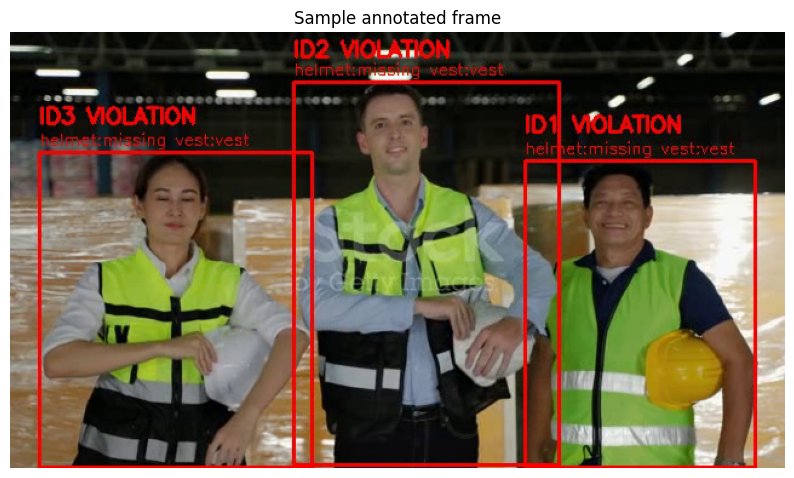

In [15]:
# Peek at one annotated frame inline (full video is in OUTPUT_VIDEO, download it from the Files pane)
cap = cv2.VideoCapture(OUTPUT_VIDEO)
cap.set(cv2.CAP_PROP_POS_FRAMES, cap.get(cv2.CAP_PROP_FRAME_COUNT) // 2)
ok, frame = cap.read()
cap.release()
if ok:
    plt.figure(figsize=(10, 6))
    plt.imshow(frame[:, :, ::-1])
    plt.axis("off")
    plt.title("Sample annotated frame")
    plt.show()

**What this tells us about the real use case.** The pipeline processed 444 frames, tracked **3**
unique people, flagged **all 3** as a violation at some point, and **372/444 frames (84%)**
contained at least one flagged violation.

That sounds alarmingly high, but checking the sample annotated frame above against the source
video confirms it's the *correct* read, not a pipeline bug: all three tracked people are wearing
their hi-vis vests properly (correctly matched as `vest:vest`, i.e. compliant) but are each holding
their hard hat in their hands rather than wearing it -- so `helmet:missing` is an accurate
detection of a real violation, not a false alarm. In other words, on this particular clip the
system is working as designed: it correctly separates the vest check (compliant) from the helmet
check (violation) per person, using the tracked ID to keep each person's verdict consistent across
frames rather than flickering.

The one caveat I can't fully rule out without ground-truth labels for the video itself: this clip
looks like stock/demo footage (there's a visible stock-photo watermark in a couple of frames)
rather than a real, continuous construction-site camera feed, so it's a different visual domain
from the Construction-PPE training photos (lighting, staging, camera framing). That domain gap
could also be inflating the violation rate somewhat on top of the genuine "helmet in hand" cases --
I'd want to validate this pipeline against a second, unrelated video (or hand-label a short clip)
before trusting the 84% figure as a real-world violation rate rather than a demo-specific one.

## 6. [Deliverable 5] Deployment & Export

In [16]:
export_path = ppe_model.export(format="onnx", imgsz=640, simplify=True)
print("Exported to:", export_path)

Ultralytics 8.4.123 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/ppe_capstone/runs/detect/runs_ppe/train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (5.1 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 249ms
Prepared 4 packages in 1.89s
Installed 4 packages in 256ms
 + colorama==0.4.6
 + onnx==1.22.0
 + onnxruntime==1.29.0
 + onnxslim==0.1.96

requirements: AutoUpdate success ✅ 3.0s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 20...
ONNX: slimming with onnxslim 0.1.96...
ONNX: export success ✅ 5.5s, saved as '